# Importing necessary modules

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Loading and Exploring Dataset

In [2]:
df = pd.read_csv('archive/Titanic-Dataset.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.shape

(891, 12)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [5]:
(891-714)/891 * 100

19.865319865319865

# Dropping null age rows

In [6]:
df.dropna(axis = 'rows', subset = 'Age', inplace = True)

In [7]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Who survived more: males or females?

In [8]:
sex_grp = df.groupby(by = 'Sex')
sex_grp['Survived'].mean()

Sex
female    0.754789
male      0.205298
Name: Survived, dtype: float64

#### On average the survival rate of females were more than that of men

## Did passenger class affect survival chances?

In [9]:
class_grp = df.groupby('Pclass')
class_grp['Survived'].mean()

Pclass
1    0.655914
2    0.479769
3    0.239437
Name: Survived, dtype: float64

#### Yes Passenger Class did affect their rate of survival

In [10]:
bins = [0, 16, 60, 100]
labels = ['Child (0-16)', 'Adult (17-60)', 'Senior (61+)']
df['Age_Group'] = pd.cut(df['Age'], bins = bins, labels = labels)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_Group
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Adult (17-60)
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Adult (17-60)
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Adult (17-60)
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Adult (17-60)
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Adult (17-60)


## What was the survival rate by age group?

In [11]:
age_grp = df.groupby('Age_Group')
age_grp['Survived'].mean()

Age_Group
Child (0-16)     0.550000
Adult (17-60)    0.388514
Senior (61+)     0.227273
Name: Survived, dtype: float64

#### On average the child group aged between 0 - 16 years was more likely to survive followed by adult group aged between 17 - 60 years and finally the senior group aged 61+ years

# Visualizations

## Survival Rate Based on Gender

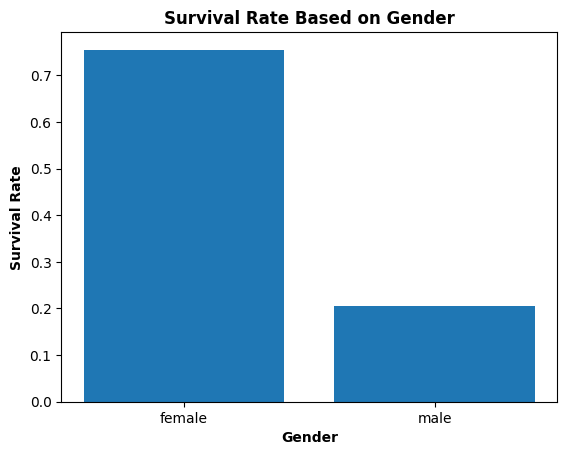

In [12]:
plt.bar(sex_grp['Survived'].mean().index, sex_grp['Survived'].mean())
plt.title('Survival Rate Based on Gender', fontweight = 'bold')
plt.xlabel('Gender', fontweight = 'bold')
plt.ylabel('Survival Rate', fontweight = 'bold')
plt.show()

## Survival Rate Based on Passenger Class

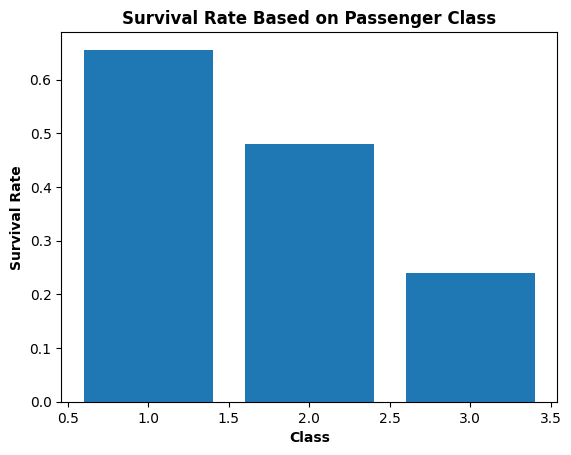

In [13]:
plt.bar(class_grp['Survived'].mean().index , class_grp['Survived'].mean())
plt.title('Survival Rate Based on Passenger Class', fontweight = 'bold')
plt.xlabel('Class', fontweight = 'bold')
plt.ylabel('Survival Rate', fontweight = 'bold')
plt.show()

## Histogram of Survived Passenger Ages

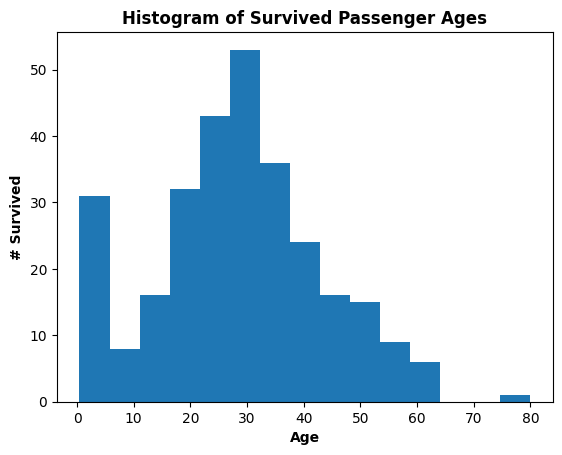

In [14]:
plt.hist(df['Age'][df['Survived'] == 1], bins = 15)
plt.title('Histogram of Survived Passenger Ages', fontweight = 'bold')
plt.xlabel('Age', fontweight = 'bold')
plt.ylabel('# Survived', fontweight = 'bold')
plt.show()